
<div style="text-align: center; line-height: 0; padding-top: 9px;">
  <img
    src="https://databricks.com/wp-content/uploads/2018/03/db-academy-rgb-1200px.png"
    alt="Databricks Learning"
  >
</div>


# Demo - Parse Documents to Structured Data

## Overview

In this demo, we’ll explore how to parse unstructured documents into structured data using Databricks’ **AI-powered document parsing** capabilities. This process enables you to extract tables, images, and text from files stored in a volume, making it easier to analyze, search, and build downstream workflows.

In most real-world retrieval agent use cases, you’ll encounter documents that need to be parsed to create a structured knowledge base. This knowledge base can then be used to provide additional context to language models.

## Learning Objectives
By the end of this demo, you will be able to:
- **Parse** multi-format documents (PDF, DOCX) using the `ai_parse_document()` AI function in both SQL and Python.
- **Inspect** and understand the parsed output schema.
- **Identify** and interpret key metadata fields in the parsed output.
- **Visualize** and debug parsed document content.

## Requirements:
- A volume containing sample documents. **This is created with setup code for you.**
- **Serverless Compute (environment version 5)**. Follow the instructions [here](https://docs.databricks.com/aws/en/compute/serverless/dependencies#-select-an-environment-version) to select the appropriate environment version.
- Required libraries are added to **Dependencies** of Serverless compute configuration.



## Setup

Run the following cells to configure the classroom environment. Volume name that contains sample documents and will be used in this demo printed below.

In [0]:
%run ../Includes/Classroom-Setup-02

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


**Set default catalog and schema:**

Default catalog and schema are set.


**Prepare Datasets:**

⏳ Creating volume orion_docs ...
⏳ Copying files from /Volumes/dbacademy/data/orion_docs to /Volumes/dbacademy/labuser15785576_1783348796/orion_docs ...
✅ Files copied to /Volumes/dbacademy/labuser15785576_1783348796/orion_docs.
⏳ Creating volume orion_text ...
⏳ Copying files from /Volumes/dbacademy/data/orion_text to /Volumes/dbacademy/labuser15785576_1783348796/orion_text ...
✅ Files copied to /Volumes/dbacademy/labuser15785576_1783348796/orion_text.


**Checking for right compute environment:**

✅ Environment check passed: Serverless 5 detected.


**Variables needed for this demo/lab:**

✍️ Sample documents volume: dbacademy.labuser15785576_1783348796.orion_docs


Complete the following steps to view one of the PDF files stored in your volume. Follow these instructions using the volume name printed above.

1. In the workspace sidebar, click on *Catalog* to open the data explorer.
1. Select the appropriate **catalog** for your environment.
1. Expand the relevant **schema (`datasets`)** within the catalog.
1. Locate and expand the **orion-docs** volume.
1. Download the **01_Orion_A1_Product_Overview.pdf** file to your local machine.
1. Open the file and review its contents to understand the document before parsing.


## A. Parsing Documents with AI

In this section, we’ll learn how to use the **`ai_parse_document` AI function** to extract structured data from unstructured documents. This AI function automatically identifies and extracts text, tables, and images from files such as PDFs and images. We’ll demonstrate both SQL and Python approaches, and explain the key metadata fields produced by the parser. This capability is valuable for automating document processing and enabling advanced analytics.

**🚨 Note:** You must use **Version 2** of `ai_parse_document` to get the parsed format covered in this demo.

### A1. Parsing Documents with Python

**Python** is ideal for flexible, interactive workflows and integration with machine learning or custom logic. Here, we use the Spark DataFrame API and the `expr` function to call `ai_parse_document` on each file. This lets you inspect results, apply further transformations, or build ML pipelines.

After running the code, review the DataFrame output to see how each document is parsed. If your volume is empty, check your path and permissions.

The `ai_parse_document` AI function accepts options such as:
- **`version`**: The parser version to use (e.g., `'2.0'`).
- **`imageOutputPath`**: Where to store extracted images.
- **`descriptionElementTypes`**: Which elements to extract (e.g., `*`, `table`, `image`, `text`).


**Note:** We are dropping the binary content field as `display` function doesn't show the result. Binary field is too long to display.

In [0]:
user_docs_path

'/Volumes/dbacademy/labuser15785576_1783348796/orion_docs'

In [0]:
from pyspark.sql.functions import expr

# Read all files from the documents volume
docs_df = spark.read.format("binaryFile").load(user_docs_path)

In [0]:
# Parse each document using ai_parse_document (use expr to call the SQL AI function)
parsed_df = docs_df.withColumn("parsed_content", 
                               expr(f"""ai_parse_document(content, map(
                                    "version", "2.0",
                                    "imageOutputPath", "{user_docs_path}/parsed_images/"
                                   ))""")
                              )
# Drop binary content
parsed_df = parsed_df.drop("content")

# Display a sample of the parsed results
display(parsed_df)

path modificationTime length parsed_content dbfs:/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/04_Orion_Vision_Module_Reference.pdf 2026-07-06T15:34:56.000Z 8551622 {"document":{"elements":[{"bbox":[{"coord":[383,144,674,177],"page_id":0}],"confidence":0.9993,"content":"Orion Robotics","description":null,"id":0,"type":"title"},{"bbox":[{"coord":[299,251,759,277],"page_id":0}],"confidence":0.9991,"content":"Orion A1 – Vision Module Reference","description":null,"id":1,"type":"title"},{"bbox":[{"coord":[309,304,749,322],"page_id":0}],"confidence":0.9902,"content":"© 2025 Orion Robotics – Vision Systems Engineering Division","description":null,"id":2,"type":"text"},{"bbox":[{"coord":[116,348,941,490],"page_id":0}],"confidence":0.9914,"content":"The Orion A1 vision module enables spatial awareness and visual understanding across a\nrange of dynamic environments. It features dual 120° stereo cameras mounted within the head\nassembly, providing depth perception and object tracking capabilities. This subsystem operates\nat 60 frames per second, continuously fusing imagery from visible and infrared bands to ensure\nreliable navigation, obstacle avoidance, and human interaction.","description":null,"id":3,"type":"text"},{"bbox":[{"coord":[116,516,939,628],"page_id":0}],"confidence":0.9902,"content":"Each camera assembly is independently adjustable to correct for manufacturing tolerances, ensuring sub-millimetre alignment precision. The system uses depth triangulation to generate a real-time 3D model of its surroundings, which is then passed to the motion controller for situational adaptation.","description":null,"id":4,"type":"text"},{"bbox":[{"coord":[195,648,862,1096],"page_id":0}],"confidence":0.9925,"content":"","description":"A white, humanoid robot with large eyes and a smooth, rounded head is depicted in a close-up illustration.","id":5,"type":"figure"},{"bbox":[{"coord":[282,1099,776,1116],"page_id":0}],"confidence":0.9909,"content":"Figure 1. Orion A1 humanoid vision module with dual stereo cameras.","description":null,"id":6,"type":"caption"},{"bbox":[{"coord":[117,104,409,130],"page_id":1}],"confidence":0.9996,"content":"1. Calibration and Alignment","description":null,"id":7,"type":"section_header"},{"bbox":[{"coord":[115,147,928,291],"page_id":1}],"confidence":0.9897,"content":"To achieve high-precision depth mapping, the Orion A1 vision module requires regular calibration. Technicians initiate this process using the Orion Vision Calibration Tool (OVCT), which employs checkerboard patterns to correct lens distortion and compute stereo alignment parameters. Calibration should be performed in controlled lighting conditions to minimize reflection artifacts that could mislead the disparity map generator.","description":null,"id":8,"type":"text"},{"bbox":[{"coord":[116,312,925,424],"page_id":1}],"confidence":0.984,"content":"Once calibration is complete, the firmware stores a unique intrinsics profile for each camera.\nAny deviation exceeding 0.02 degrees between optical axes triggers a maintenance alert.\nDuring autonomous operation, the robot uses visual landmarks to continuously self-correct its\norientation when GPS or motion data is unavailable.","description":null,"id":9,"type":"text"},{"bbox":[{"coord":[181,444,876,865],"page_id":1}],"confidence":0.9661,"content":"","description":"Three stylized robot heads are arranged vertically, with a checkerboard pattern and a small robot at the top and bottom.","id":10,"type":"figure"},{"bbox":[{"coord":[131,869,927,911],"page_id":1}],"confidence":0.9869,"content":"Figure 2. Left: Calibration using checkerboard pattern. Center: Low-light depth projection. Right: Field technician performing lens maintenance.","description":null,"id":11,"type":"caption"},{"bbox":[{"coord":[117,104,429,129],"page_id":2}],"confidence":0.9997,"content":"2. Operation and Maintenance","description":null,"id":12,"type":"section_header"},{"bbox":[{"coord":[116,147,917,291],"page_id":2}],"confiden

List the files in your volumes path. 

  Notice it contains both the original PDF files used for the demonstration and the new `/parsed_images/` directory, which holds all of the output images generated during parsing.

In [0]:
spark.sql(f"LIST '{user_docs_path}'").display()

path,name,size,modification_time
/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/01_Orion_A1_Product_Overview.pdf,01_Orion_A1_Product_Overview.pdf,39766,1783352097000
/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/02_Orion_Battery_Management_System_Manual.pdf,02_Orion_Battery_Management_System_Manual.pdf,104554,1783352097000
/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/03_Orion_Motion_Controller_Firmware_Guide_v6.pdf,03_Orion_Motion_Controller_Firmware_Guide_v6.pdf,1279237,1783352096000
/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/04_Orion_Vision_Module_Reference.pdf,04_Orion_Vision_Module_Reference.pdf,8551622,1783352096000
/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/06_Orion_Safety_and_Compliance_Sheet_v2.docx,06_Orion_Safety_and_Compliance_Sheet_v2.docx,1109163,1783352097000
/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/07_Troubleshooting_Playbook.png,07_Troubleshooting_Playbook.png,2001981,1783352096000
/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/08_Orion Robotics Engineering Notes.pdf,08_Orion Robotics Engineering Notes.pdf,42852,1783352097000
/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/parsed_images/,parsed_images/,0,1783353034806


Run the cell below and observe that the `/parsed_images/` directory in your volume now contains a series of output images.

In [0]:
spark.sql(f"LIST '{user_docs_path}/parsed_images'").display()

path,name,size,modification_time
/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/parsed_images/07c6089df3f700ba01e9cfa73be27371e20485759695aafb33041e1c926d16c3.jpg,07c6089df3f700ba01e9cfa73be27371e20485759695aafb33041e1c926d16c3.jpg,133388,1783352537000
/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/parsed_images/25f6bb9bffa863eeefe549f38d47f22f541bd9df21c13ae70f47bdbe385bd3d7.jpg,25f6bb9bffa863eeefe549f38d47f22f541bd9df21c13ae70f47bdbe385bd3d7.jpg,110411,1783352529000
/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/parsed_images/30c939195bc326c907b0d8a9a0bcb4ff393d0f8d8578fefe08f496ea3c135c40.jpg,30c939195bc326c907b0d8a9a0bcb4ff393d0f8d8578fefe08f496ea3c135c40.jpg,128359,1783352533000
/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/parsed_images/324ce7db38eac2b33a95c96c3b262cfce7d024c4530c8184cdf5bb168199649b.jpg,324ce7db38eac2b33a95c96c3b262cfce7d024c4530c8184cdf5bb168199649b.jpg,141770,1783352532000
/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/parsed_images/550f6afb6a4597e9fe6cbd93fd9c66924a70d422a68b2a451aa3025266737bca.jpg,550f6afb6a4597e9fe6cbd93fd9c66924a70d422a68b2a451aa3025266737bca.jpg,139171,1783352529000
/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/parsed_images/576666df171c2674f129bba83c4a01180c2a8a2f79f3ae2e137fe1ddbc922ef2.jpg,576666df171c2674f129bba83c4a01180c2a8a2f79f3ae2e137fe1ddbc922ef2.jpg,110392,1783352532000
/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/parsed_images/64ee393b76542080a372b17ec18a11fda5ded7ebc2b1fd3afdaa26cbe2c38bc6.jpg,64ee393b76542080a372b17ec18a11fda5ded7ebc2b1fd3afdaa26cbe2c38bc6.jpg,96750,1783352533000
/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/parsed_images/7cbc2c696471f07ca0587e3c2001c23bafebb9a246c6477270e834f2f05b5029.jpg,7cbc2c696471f07ca0587e3c2001c23bafebb9a246c6477270e834f2f05b5029.jpg,135098,1783352529000
/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/parsed_images/8570010661e82fe5fc8210d9ce2e2cb7f75ae082e1c6fe12591982dac52490ee.jpg,8570010661e82fe5fc8210d9ce2e2cb7f75ae082e1c6fe12591982dac52490ee.jpg,92987,1783352532000
/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/parsed_images/966d001f54f2a51a97be22936342b50fcea6e86142261fbfe193927e81166813.jpg,966d001f54f2a51a97be22936342b50fcea6e86142261fbfe193927e81166813.jpg,124021,1783352532000


### A2. Parsing with SQL

**SQL** is great for batch processing and easy integration with Lakehouse tables. The example below parses all documents in the specified volume and returns a structured result.

This approach is ideal for scheduled jobs or when you want to persist results in a table.

**Note:** If the image output path is not defined, the images extracted during the previous parsing are also parsed. 

In [0]:
parsed_df_sql = spark.sql(f"""
SELECT
  path,
  ai_parse_document(
    content,
    map(
      'version', '2.0'
    )
  ) as parsed_doc
FROM read_files('{user_docs_path}', format => 'binaryFile')""")

display(parsed_df_sql)

path parsed_doc dbfs:/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/04_Orion_Vision_Module_Reference.pdf {"document":{"elements":[{"bbox":[{"coord":[383,144,674,177],"page_id":0}],"confidence":0.9994,"content":"Orion Robotics","description":null,"id":0,"type":"title"},{"bbox":[{"coord":[299,251,759,277],"page_id":0}],"confidence":0.9991,"content":"Orion A1 – Vision Module Reference","description":null,"id":1,"type":"title"},{"bbox":[{"coord":[309,304,749,322],"page_id":0}],"confidence":0.9891,"content":"© 2025 Orion Robotics – Vision Systems Engineering Division","description":null,"id":2,"type":"text"},{"bbox":[{"coord":[116,348,941,490],"page_id":0}],"confidence":0.988,"content":"The Orion A1 vision module enables spatial awareness and visual understanding across a range of dynamic environments. It features dual 120° stereo cameras mounted within the head assembly, providing depth perception and object tracking capabilities. This subsystem operates at 60 frames per second, continuously fusing imagery from visible and infrared bands to ensure reliable navigation, obstacle avoidance, and human interaction.","description":null,"id":3,"type":"text"},{"bbox":[{"coord":[116,516,939,628],"page_id":0}],"confidence":0.9901,"content":"Each camera assembly is independently adjustable to correct for manufacturing tolerances, ensuring sub-millimetre alignment precision. The system uses depth triangulation to generate a real-time 3D model of its surroundings, which is then passed to the motion controller for situational adaptation.","description":null,"id":4,"type":"text"},{"bbox":[{"coord":[195,648,862,1096],"page_id":0}],"confidence":0.9925,"content":"","description":"A white, humanoid robot with large eyes and a smooth, rounded head is depicted in a close-up illustration.","id":5,"type":"figure"},{"bbox":[{"coord":[282,1099,776,1116],"page_id":0}],"confidence":0.9917,"content":"Figure 1. Orion A1 humanoid vision module with dual stereo cameras.","description":null,"id":6,"type":"caption"},{"bbox":[{"coord":[117,104,409,130],"page_id":1}],"confidence":0.9997,"content":"1. Calibration and Alignment","description":null,"id":7,"type":"section_header"},{"bbox":[{"coord":[115,147,928,291],"page_id":1}],"confidence":0.9896,"content":"To achieve high-precision depth mapping, the Orion A1 vision module requires regular calibration. Technicians initiate this process using the Orion Vision Calibration Tool (OVCT), which employs checkerboard patterns to correct lens distortion and compute stereo alignment parameters. Calibration should be performed in controlled lighting conditions to minimize reflection artifacts that could mislead the disparity map generator.","description":null,"id":8,"type":"text"},{"bbox":[{"coord":[116,312,925,424],"page_id":1}],"confidence":0.9843,"content":"Once calibration is complete, the firmware stores a unique intrinsics profile for each camera.\nAny deviation exceeding 0.02 degrees between optical axes triggers a maintenance alert.\nDuring autonomous operation, the robot uses visual landmarks to continuously self-correct its\norientation when GPS or motion data is unavailable.","description":null,"id":9,"type":"text"},{"bbox":[{"coord":[178,443,877,865],"page_id":1}],"confidence":0.9569,"content":"","description":"Three robotic figures, including one with a baseball cap, are illustrated in a row with a checkerboard pattern on the left.","id":10,"type":"figure"},{"bbox":[{"coord":[131,869,927,911],"page_id":1}],"confidence":0.9867,"content":"Figure 2. Left: Calibration using checkerboard pattern. Center: Low-light depth projection. Right: Field technician performing lens maintenance.","description":null,"id":11,"type":"caption"},{"bbox":[{"coord":[117,104,429,129],"page_id":2}],"confidence":0.9997,"content":"2. Operation and Maintenance","description":null,"id":12,"type":"section_header"},{"bbox":[{"coord":[116,147,917,291],"page_id":2}],"confidence":0.9911,"content":"In field conditions, the Orion vision mo

### A3. Understanding Parsed Document Metadata

The output of `ai_parse_document` includes a rich metadata structure in the `parsed_content` field. **Key fields include:**

- **`parsed:document:pages`**: A list of page objects, each with:
  - **`page_number`**: The page’s index in the document.
  - **`text`**: Extracted text content.
  - **`tables`**: Structured table data, if detected.
  - **`images`**: Extracted images, often as base64 or file references.
- **`parsed:document:metadata`**: General document info (file name, size, format).

*You can use these fields to build search indexes, automate reporting, or feed downstream ML models. For large documents, consider paginating or filtering results. If some fields are missing, check the document type and parser options.*

In [0]:
# Display document path and key metadata fields
from pyspark.sql.functions import expr

# Select key metadata fields using expr for nested fields
meta_df = parsed_df.select(
    "path",
    expr("parsed_content:document:pages"),
    expr("parsed_content:document:elements"),
    expr("parsed_content:error_status"),
    expr("parsed_content:corrupted_data"),
    expr("parsed_content:metadata")
)

display(meta_df)

path pages elements error_status corrupted_data metadata dbfs:/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/04_Orion_Vision_Module_Reference.pdf [{"id":0,"image_uri":"/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/parsed_images/550f6afb6a4597e9fe6cbd93fd9c66924a70d422a68b2a451aa3025266737bca.jpg"},{"id":1,"image_uri":"/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/parsed_images/7cbc2c696471f07ca0587e3c2001c23bafebb9a246c6477270e834f2f05b5029.jpg"},{"id":2,"image_uri":"/Volumes/dbacademy/labuser15785576_1783348796/orion_docs/parsed_images/25f6bb9bffa863eeefe549f38d47f22f541bd9df21c13ae70f47bdbe385bd3d7.jpg"}] [{"bbox":[{"coord":[383,144,674,177],"page_id":0}],"confidence":0.9994,"content":"Orion Robotics","description":null,"id":0,"type":"title"},{"bbox":[{"coord":[299,251,759,277],"page_id":0}],"confidence":0.9991,"content":"Orion A1 – Vision Module Reference","description":null,"id":1,"type":"title"},{"bbox":[{"coord":[309,304,749,322],"page_id":0}],"confidence":0.99,"content":"© 2025 Orion Robotics – Vision Systems Engineering Division","description":null,"id":2,"type":"text"},{"bbox":[{"coord":[116,348,941,490],"page_id":0}],"confidence":0.9914,"content":"The Orion A1 vision module enables spatial awareness and visual understanding across a\nrange of dynamic environments. It features dual 120° stereo cameras mounted within the head\nassembly, providing depth perception and object tracking capabilities. This subsystem operates\nat 60 frames per second, continuously fusing imagery from visible and infrared bands to ensure\nreliable navigation, obstacle avoidance, and human interaction.","description":null,"id":3,"type":"text"},{"bbox":[{"coord":[116,516,939,628],"page_id":0}],"confidence":0.9902,"content":"Each camera assembly is independently adjustable to correct for manufacturing tolerances, ensuring sub-millimetre alignment precision. The system uses depth triangulation to generate a real-time 3D model of its surroundings, which is then passed to the motion controller for situational adaptation.","description":null,"id":4,"type":"text"},{"bbox":[{"coord":[195,648,862,1096],"page_id":0}],"confidence":0.9925,"content":"","description":"A white, humanoid robot with large eyes and a smooth, rounded head is depicted in a close-up illustration.","id":5,"type":"figure"},{"bbox":[{"coord":[282,1099,776,1116],"page_id":0}],"confidence":0.9914,"content":"Figure 1. Orion A1 humanoid vision module with dual stereo cameras.","description":null,"id":6,"type":"caption"},{"bbox":[{"coord":[117,104,409,130],"page_id":1}],"confidence":0.9996,"content":"1. Calibration and Alignment","description":null,"id":7,"type":"section_header"},{"bbox":[{"coord":[115,147,928,291],"page_id":1}],"confidence":0.9896,"content":"To achieve high-precision depth mapping, the Orion A1 vision module requires regular calibration. Technicians initiate this process using the Orion Vision Calibration Tool (OVCT), which employs checkerboard patterns to correct lens distortion and compute stereo alignment parameters. Calibration should be performed in controlled lighting conditions to minimize reflection artifacts that could mislead the disparity map generator.","description":null,"id":8,"type":"text"},{"bbox":[{"coord":[116,312,925,424],"page_id":1}],"confidence":0.9843,"content":"Once calibration is complete, the firmware stores a unique intrinsics profile for each camera.\nAny deviation exceeding 0.02 degrees between optical axes triggers a maintenance alert.\nDuring autonomous operation, the robot uses visual landmarks to continuously self-correct its\norientation when GPS or motion data is unavailable.","description":null,"id":9,"type":"text"},{"bbox":[{"coord":[181,444,876,865],"page_id":1}],"confidence":0.9661,"content":"","description":"Three stylized robot heads are arranged side-by-side, with a checkerboard pattern and a camera device visible on the left.","id":10,"type":"figure"},{"bbox":[{"coord":[131,869,927,911],"page_id":

## B. View and Debug Parsed Document Content

After parsing, it’s important to inspect and debug the structured output to ensure quality and completeness. **Visualization** helps you validate extraction accuracy and understand how the parser handles mixed content. We’ll use a helper class to render the parsed results, making it easier to review text, tables, and images from each page.

### B1. Import DocumentRenderer Helper Class

The `DocumentRenderer` class is a utility for visualizing parsed document content in Databricks notebooks. It supports rendering text, tables, and images from each page, which is critical for document QA and workflow validation.

You can find the helper class in the **Includes** folder or as provided by your instructor. We won’t cover its implementation here—just use it to streamline your workflow and focus on interpreting results.

In [0]:
# Import the DocumentRenderer helper class
import sys, os
sys.path.append(os.path.abspath('..'))
from Includes.document_renderer import render_ai_parse_output, render_ai_parse_output_interactive

### B2. Display Parsed Results

The code below selects a document with both images and tables (if available) and uses the `DocumentRenderer` helper class to visualize its parsed content. You should see a visual representation of the document’s pages, including extracted text, tables, and images. This makes it much easier to debug and understand how the AI parser has structured the content for downstream analysis.

*If no suitable document is found, check your volume for files with mixed content or adjust the filter logic.*


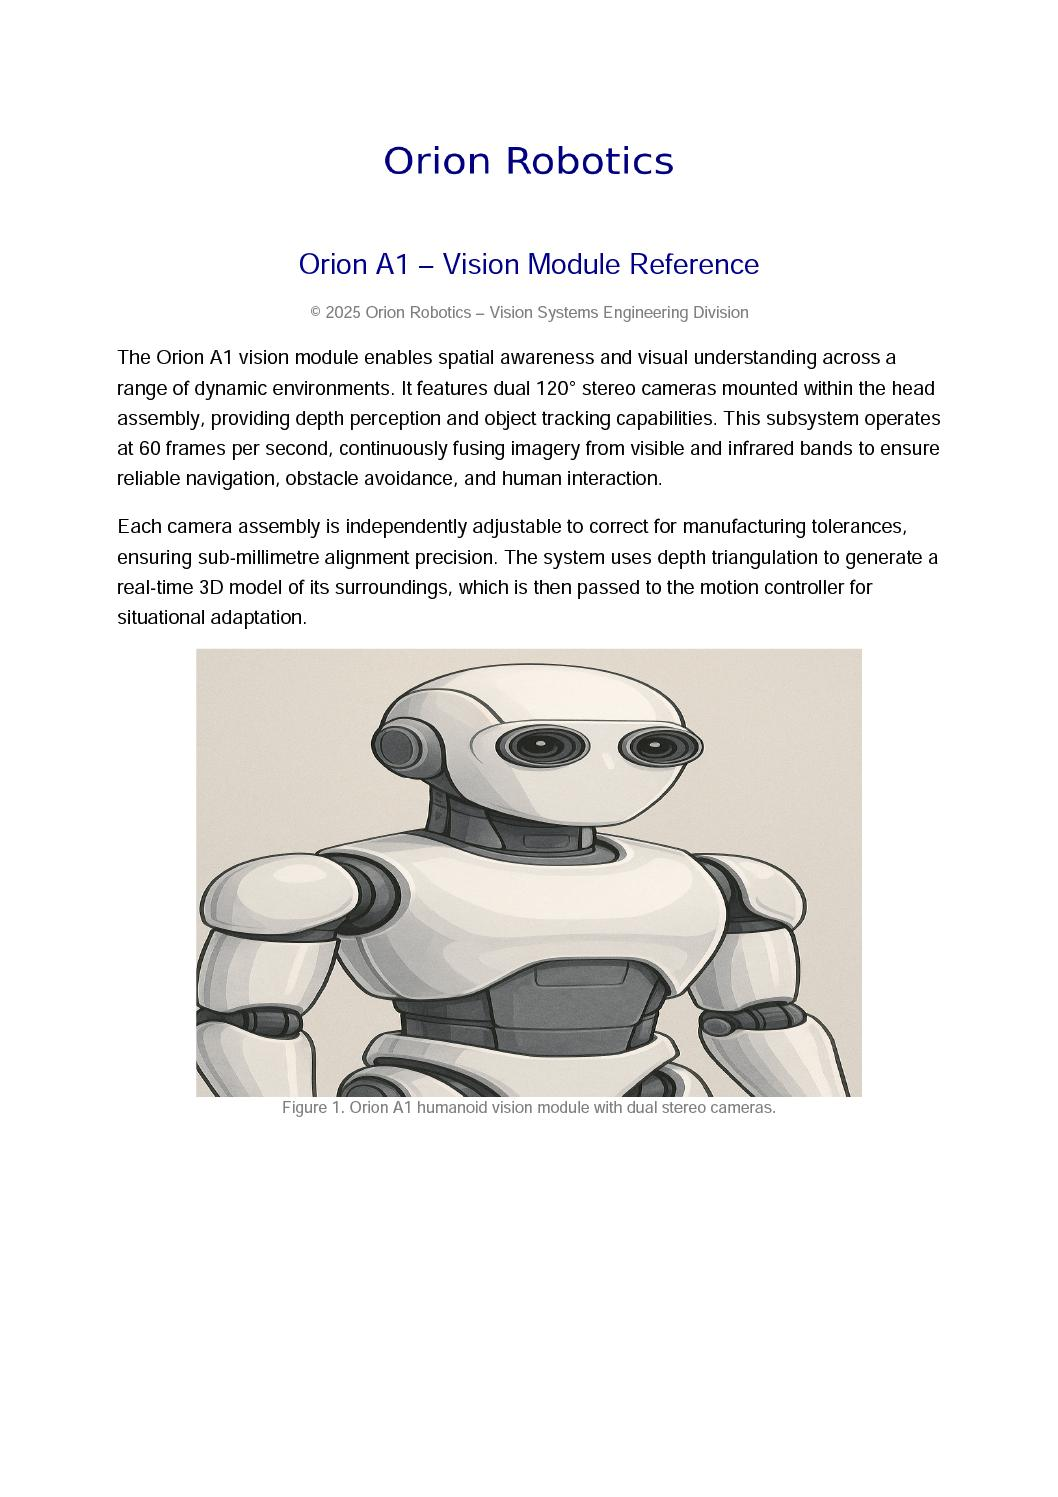


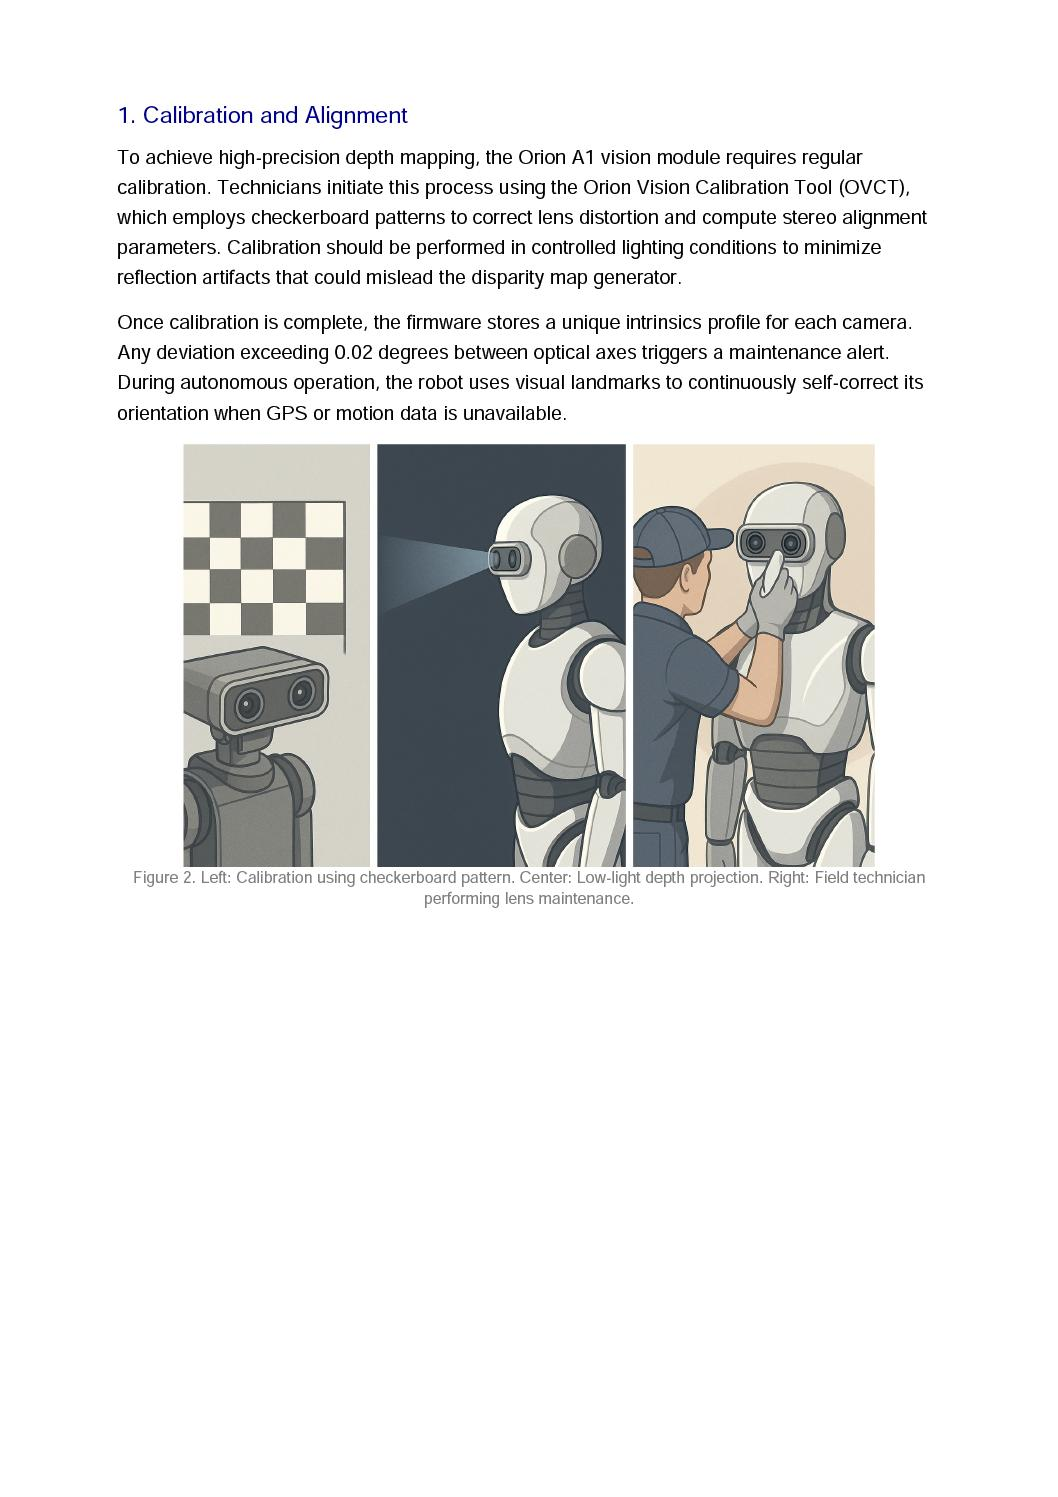


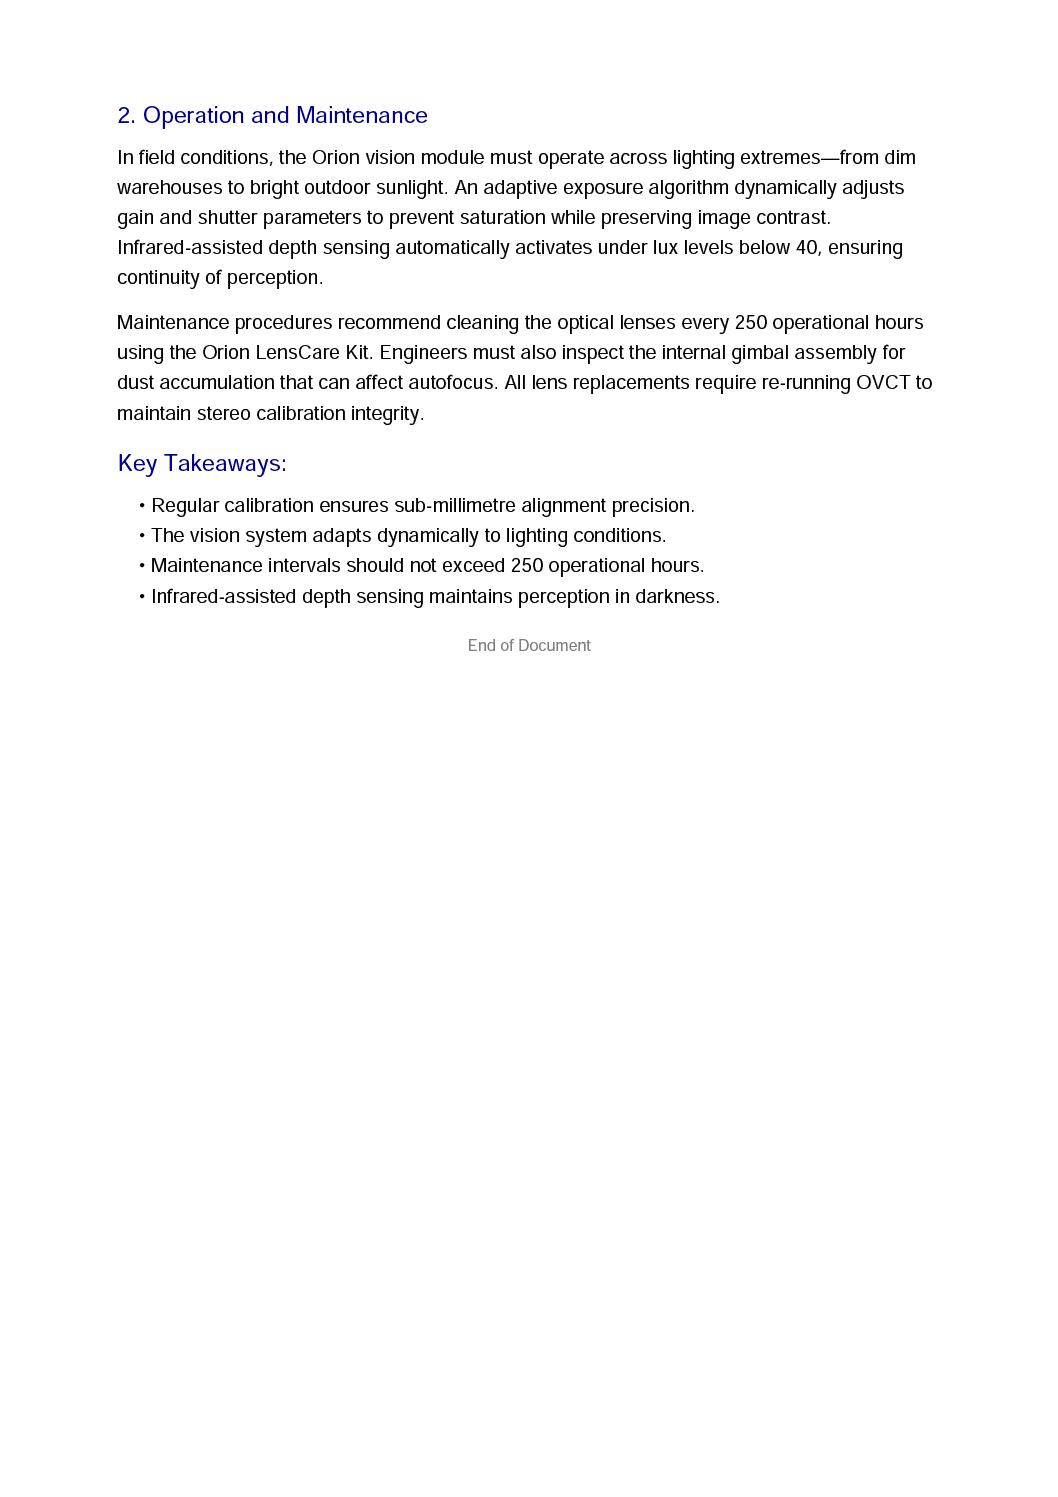

In [0]:
# Select a sample document and render its parsed content using render_ai_parse_output
sample = parsed_df.select("parsed_content").limit(1).collect()

if sample:
    doc = sample[0]["parsed_content"]
    render_ai_parse_output(doc)
else:
    print("No parsed documents found. Please check your input volume and parsing step.")

## C. Save Parsed Results to Delta Table

Now that we’ve parsed and explored our documents, let’s save the results for further processing. The parsed content is currently in JSON format, so **we’ll need to clean and transform it** before it can be effectively used for retrieval tasks.

In [0]:
# Save the parsed results as a Delta table for easy querying and sharing
output_table = f"{catalog}.{schema}.docs_parsed"

# Overwrite the table if it already exists
parsed_df.write.format("delta").mode("overwrite").saveAsTable(output_table)

print(f"✅ Parsed results saved to Delta table: {output_table}")

✅ Parsed results saved to Delta table: dbacademy.labuser15785576_1783348796.docs_parsed


## Summary and Next Steps

You’ve learned how to parse unstructured documents using Databricks’ AI-powered `ai_parse_document` AI function in both Python and SQL. We demonstrated how to batch process files, extract structured content and metadata, and visualize results for quality assurance. By integrating these techniques, you can automate document extraction workflows and prepare data for downstream analytics or machine learning tasks.

**Key Takeaways:**
- **Automate** document parsing with the `ai_parse_document` AI function in both Python and SQL.
- **Inspect** and understand the parsed output schema, including key metadata fields like `pages`, `elements`, and `metadata`.
- **Visualize** and debug parsed results using the DocumentRenderer helper class for quality assurance and workflow validation.

For more information about the `ai_parse_document`, check the [official Databricks documentation](https://docs.databricks.com/sql/language-manual/functions/ai_parse_document.html).

&copy; 2026 Databricks, Inc. All rights reserved. Apache, Apache Spark, Spark, the Spark Logo, Apache Iceberg, Iceberg, and the Apache Iceberg logo are trademarks of the <a href="https://www.apache.org/" target="_blank">Apache Software Foundation</a>.<br/><br/><a href="https://databricks.com/privacy-policy" target="_blank">Privacy Policy</a> | <a href="https://databricks.com/terms-of-use" target="_blank">Terms of Use</a> | <a href="https://help.databricks.com/" target="_blank">Support</a>